
Annual Average Gold and Silver Prices

     Year   Value_Gold  Value_Silver
0    1915    19.250000      0.510000
1    1916    19.470000      0.670000
2    1917    19.660000      0.840000
3    1918    19.840000      0.980000
4    1919    20.030000      1.130000
..    ...          ...           ...
107  2022  1798.956575     21.671767
108  2023  1953.688517     23.579675
109  2024  2404.577567     28.128033
110  2025  3472.540975     41.501500
111  2026  4881.619800     96.083200

[112 rows x 3 columns]


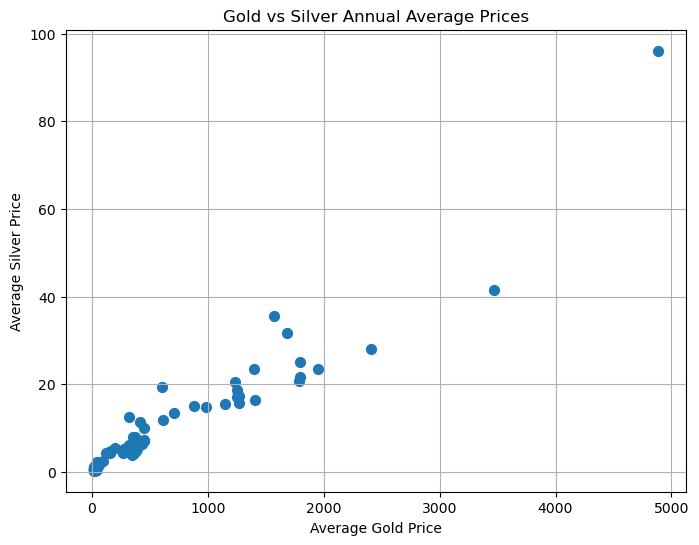

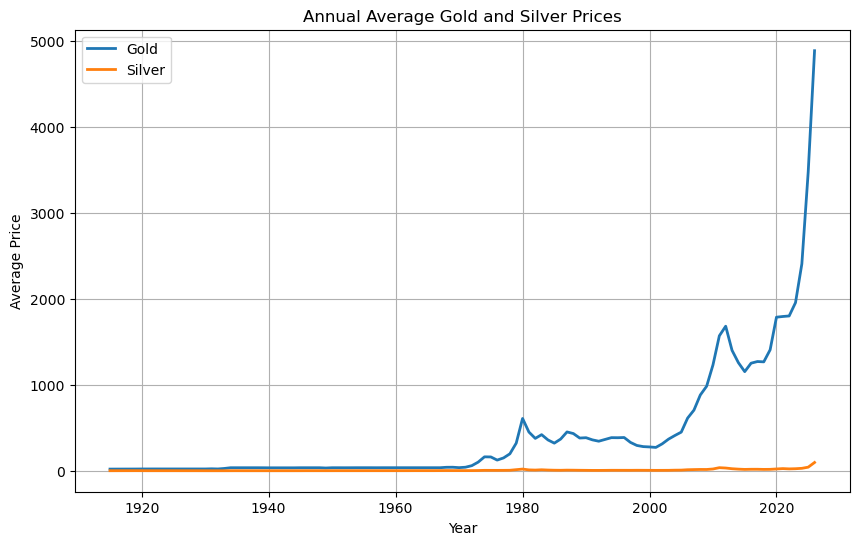


Figures saved successfully!
Scatter Plot : B4_Gold_vs_Silver_Scatter_Plot.png
Line Graph   : B4_Gold_Silver_Line_Graph.png


In [2]:
#B4 .Create a scatter plot comparing Gold and Silver annual average prices.  
#Gold vs Silver Annual Average Prices
# Scatter Plot and Line Graph

import pandas as pd
import matplotlib.pyplot as plt
import os

# Load datasets
gold = pd.read_csv(r"E:\UE class schedule\DATA SCIENCE\DSB Project\Gold 100years.csv")
silver = pd.read_csv(r"E:\UE class schedule\DATA SCIENCE\DSB Project\silver 100 years.csv")

# Convert Date columns
gold["Date"] = pd.to_datetime(gold["Date"], dayfirst=True)
silver["Date"] = pd.to_datetime(silver["Date"], dayfirst=True)

# Extract Year
gold["Year"] = gold["Date"].dt.year
silver["Year"] = silver["Date"].dt.year

# Calculate Annual Average Prices
gold_yearly = (
    gold.groupby("Year")["Value"]
    .mean()
    .reset_index()
)

silver_yearly = (
    silver.groupby("Year")["Value"]
    .mean()
    .reset_index()
)

# Merge Gold & Silver Data
merged = pd.merge(
    gold_yearly,
    silver_yearly,
    on="Year",
    suffixes=("_Gold", "_Silver")
)

# Display Table
print("\nAnnual Average Gold and Silver Prices\n")
print(merged)

# Create Folder for Figures
save_folder = r"E:\UE class schedule\DATA SCIENCE\DSB Project\Figures"
os.makedirs(save_folder, exist_ok=True)

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    merged["Value_Gold"],
    merged["Value_Silver"],
    s=50
)

plt.title("Gold vs Silver Annual Average Prices")
plt.xlabel("Average Gold Price")
plt.ylabel("Average Silver Price")
plt.grid(True)

# Save Scatter Plot
plt.savefig(
    os.path.join(
        save_folder,
        "B4_Gold_vs_Silver_Scatter_Plot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Line Graph
plt.figure(figsize=(10,6))

plt.plot(
    merged["Year"],
    merged["Value_Gold"],
    label="Gold",
    linewidth=2
)

plt.plot(
    merged["Year"],
    merged["Value_Silver"],
    label="Silver",
    linewidth=2
)

plt.title("Annual Average Gold and Silver Prices")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.legend(loc="upper left")
plt.grid(True)

# Save Line Graph
plt.savefig(
    os.path.join(
        save_folder,
        "B4_Gold_Silver_Line_Graph.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nFigures saved successfully!")
print("Scatter Plot : B4_Gold_vs_Silver_Scatter_Plot.png")
print("Line Graph   : B4_Gold_Silver_Line_Graph.png")